# **All About Softmax Regression**

## What is Softmax Regression?
Softmax Regression (also called **Multinomial Logistic Regression**) is a **supervised classification algorithm** that extends Logistic Regression to handle **multiple classes** (3 or more).

> Logistic Regression → Binary (2 classes)  
> Softmax Regression → Multiclass (3+ classes)

---

## Why Do We Need It?
Logistic Regression uses **Sigmoid** which outputs a single probability for 2 classes.  
When we have 3+ classes, we need probabilities **for each class** that **sum to 1** — that's exactly what **Softmax** does.

| Scenario | Algorithm |
|---|---|
| Spam or Not Spam | Logistic Regression |
| Cat, Dog, or Bird | Softmax Regression |
| Digit 0–9 | Softmax Regression |

---

## Where Is It Used?
- Handwritten digit recognition (MNIST)
- Image classification (cat/dog/bird)
- NLP — next word prediction
- Medical diagnosis with multiple conditions
- News article topic classification

---

## How It Works (Mechanism)
```
Input Features → Scores (one per class) → Softmax → Probabilities → argmax → Class
     X              z = X · theta           σ(z)       sum = 1        pick highest
```

**1. Compute Scores for each class**
$$z_k = \theta_k^T x \quad \text{for each class } k$$

Each class has its **own weight vector** → theta is a matrix of shape **(features × classes)**

**2. Softmax Function** — converts scores to probabilities
$$P(y=k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

- Every output is between 0 and 1
- All class probabilities **always sum to 1**
- The class with the **highest probability wins**

**3. Numerical Stability Trick**
$$z_{\text{shifted}} = z - \max(z)$$
Subtracting max before applying exp() **prevents overflow** without changing the result.

**4. Decision Rule**
$$\hat{y} = \arg\max_k \, P(y=k \mid x)$$

**5. Loss Function — Categorical Cross-Entropy**
$$\text{Loss} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_{ik} \log(\hat{p}_{ik})$$

> Penalizes the model when it assigns low probability to the correct class.

**6. Gradient & Weight Update**
$$\text{gradient} = \frac{1}{m} X^T (\hat{P} - Y)$$
$$\theta = \theta - \alpha \cdot \text{gradient}$$

---

## One-Hot Encoding — Why It's Needed

Softmax outputs a **probability vector**, so the target must also be a vector.
```
y = [0, 1, 2]   →   y_onehot = [[1, 0, 0],
                                  [0, 1, 0],
                                  [0, 0, 1]]
```
Without this, we can't compute the error between output and target properly.

---

## Key Assumptions
- Target variable has **3 or more discrete classes**
- Classes are **mutually exclusive** (one sample = one class)
- Linear decision boundary is **sufficient**
- Features have **no extreme multicollinearity**

---

## Advantages
| ✅ Pro | Reason |
|---|---|
| Handles multiclass natively | No need for One-vs-Rest tricks |
| Probabilistic output | Confidence score for each class |
| Simple & interpretable | Weights show per-class feature importance |
| Efficient | Closed-form gradient, fast convergence |

---

## Problems & Limitations
| ❌ Problem | Explanation |
|---|---|
| Linear boundary only | Fails on complex non-linear data |
| Mutually exclusive classes | Can't handle multi-label problems |
| Sensitive to outliers | Skews the decision boundaries |
| Feature scaling needed | Large values dominate scores |
| Scales with classes | More classes = larger theta matrix |

---

## Logistic vs Softmax Regression

| | Logistic Regression | Softmax Regression |
|---|---|---|
| Classes | 2 (binary) | 3+ (multiclass) |
| Output function | Sigmoid | Softmax |
| Output | Single probability | Probability per class |
| Weights | Vector (n,) | Matrix (n, k) |
| Target format | 0 or 1 | One-hot encoded |
| Loss | Binary Cross-Entropy | Categorical Cross-Entropy |
| Decision | prob ≥ 0.5 | argmax(probabilities) |

> Logistic Regression is actually a **special case** of Softmax with k=2 classes.

---

## The Big Picture
```
                   ┌─────────────────────────────────┐
                   │   Scores (z = X · theta)         │
  Input X    →     │   z_fail, z_pass, z_distinction  │
                   └────────────┬────────────────────┘
                                ↓
                   ┌─────────────────────────────────┐
                   │   Softmax → Probabilities        │
                   │   [0.05,   0.90,   0.05]         │
                   └────────────┬────────────────────┘
                                ↓
                         argmax → Class 1 (Pass)
```

Softmax Regression learns **one weight vector per class** — whichever class scores highest after softmax wins. It's the natural bridge between simple binary classification and deep neural networks, where the final layer is almost always a Softmax.

# **Imports**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

# **Dataset Generation**

In [7]:
# Dataset Generation (Multi-class)
X, y = make_classification(n_samples=600, n_features=2, n_classes=3,n_clusters_per_class=1,
                           n_informative=2, n_redundant=0, random_state=42)


In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
# One-hot encode labels for scratch implementation
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

print("X_train shape:", X_train.shape)
print("y_train_onehot shape:", y_train_onehot.shape)

X_train shape: (420, 2)
y_train_onehot shape: (420, 3)


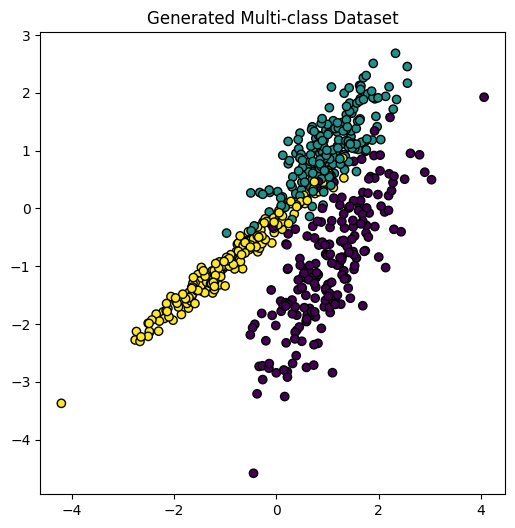

In [10]:
# Visualize dataset
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', edgecolors='k')
plt.title("Generated Multi-class Dataset")
plt.show()

# **Custom Softmax Regression Model**

In [11]:
class SoftmaxRegressionScratch:
  def __init__(self, learning_rate=0.1, n_iterations=1000):
    self.learning_rate = learning_rate
    self.n_iterations = n_iterations
    self.theta = None

  def softmax(self, z):
    # Subtract row-wise max to prevent exp() overflow (numerically stable)
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exponentials = np.exp(z_shifted)
    # Divide each exp by row sum so all class probabilities sum to 1
    sum_of_exponentials = np.sum(exponentials, axis=1, keepdims=True)
    probabilities = exponentials / sum_of_exponentials
    return probabilities

  def fit(self, X, y_onehot):
    m, n = X.shape
    # number of classes
    k = y_onehot.shape[1]
    # prepend bias column of 1s
    X_bias = np.c_[np.ones((m, 1)), X]

    # theta shape: (n_features+1, n_classes) — one weight vector per class
    self.theta = np.zeros((n+1, k))

    for i in range(self.n_iterations):
      # raw score per class per sample
      scores = X_bias.dot(self.theta)
      # convert scores → probabilities
      probs = self.softmax(scores)
      # how far predicted probs are from true labels
      error = probs - y_onehot
      # gradient shape matches theta: (n+1, k)
      gradient = (1/m) * X_bias.T.dot(error)
      self.theta -= self.learning_rate * gradient

  def predict(self, X):
    X_bias = np.c_[np.ones((X.shape[0], 1)), X]
    probs = self.softmax(X_bias.dot(self.theta))
    # return index of highest probability class
    return np.argmax(probs, axis=1)

# **Explanation of Custom Model**

## Example Dataset
| Hours Studied | Hours Slept | Result |
|---|---|---|
| 1 | 8 | Fail (0) |
| 2 | 7 | Fail (0) |
| 5 | 6 | Pass (1) |
| 6 | 5 | Pass (1) |
| 9 | 4 | Distinction (2) |
| 10 | 3 | Distinction (2) |

> **3 classes** → We can't use sigmoid (binary only). We need **Softmax** which outputs a probability for each class.

---

## Step 1: One-Hot Encode Labels
Softmax needs y as a **matrix**, not a 1D array.
```
y = [0, 0, 1, 1, 2, 2]

y_onehot = [[1, 0, 0],   ← Fail
            [1, 0, 0],   ← Fail
            [0, 1, 0],   ← Pass
            [0, 1, 0],   ← Pass
            [0, 0, 1],   ← Distinction
            [0, 0, 1]]   ← Distinction
```
Each row = one sample, each column = one class.

---

## Step 2: Add Bias Column & Initialize Theta
```
X_bias = [[1, 1, 8],    ← 1 is the bias term
          [1, 2, 7],
          [1, 5, 6],
          [1, 6, 5],
          [1, 9, 4],
          [1, 10, 3]]

theta = [[0, 0, 0],   ← shape: (n_features+1, n_classes) = (3, 3)
         [0, 0, 0],    rows = weights per feature
         [0, 0, 0]]    cols = one set of weights per class
```

---

## Step 3: Softmax Function (vs Sigmoid)

| | Sigmoid | Softmax |
|---|---|---|
| Classes | 2 (binary) | 3+ (multiclass) |
| Output | Single probability | Probability per class |
| Outputs sum to | — | Always 1.0 |

**Formula:**
$$\sigma(z_k) = \frac{e^{z_k}}{\sum_{j} e^{z_j}}$$

**Why z_shifted?** → Subtracting max(z) before exp() prevents numerical overflow. Mathematically identical, numerically stable.

---

## Step 4: One Gradient Descent Iteration (Manually)

**4a. Compute Scores**
```
scores = X_bias · theta   → shape: (6, 3)
       = all zeros initially  (since theta = 0)
```

**4b. Apply Softmax → Probabilities**
```
softmax([0, 0, 0]) = [0.33, 0.33, 0.33]

probs = [[0.33, 0.33, 0.33],   ← model is equally confused for all samples
         [0.33, 0.33, 0.33],
         [0.33, 0.33, 0.33],
         [0.33, 0.33, 0.33],
         [0.33, 0.33, 0.33],
         [0.33, 0.33, 0.33]]
```

**4c. Compute Error**
```
error = probs - y_onehot

Row 1 (Fail):        [0.33-1,  0.33-0,  0.33-0] = [-0.67,  0.33,  0.33]
Row 3 (Pass):        [0.33-0,  0.33-1,  0.33-0] = [ 0.33, -0.67,  0.33]
Row 5 (Distinction): [0.33-0,  0.33-0,  0.33-1] = [ 0.33,  0.33, -0.67]
```
> Negative error = model under-predicted that class → needs to increase weight
> Positive error = model over-predicted that class → needs to decrease weight

**4d. Compute Gradient**
```
gradient = (1/m) * X_bias.T · error   → shape: (3, 3)
```

**4e. Update Theta**
```
theta = theta - lr * gradient
      = 0     - 0.1 * gradient
```
Each column of theta = weights for one class, updated independently.

---

## Step 5: After 1000 Iterations
```
Theta converges → each class gets its own learned weight vector

predict([1, 8])  → scores → softmax → [0.91, 0.07, 0.02] → argmax → 0 (Fail) ✓
predict([5, 6])  → scores → softmax → [0.05, 0.88, 0.07] → argmax → 1 (Pass) ✓
predict([9, 4])  → scores → softmax → [0.02, 0.06, 0.92] → argmax → 2 (Distinction) ✓
```

---


## Logistic vs Softmax

| | Logistic Regression | Softmax Regression |
|---|---|---|
| Classes | 2 (binary) | 3+ (multiclass) |
| Output function | Sigmoid | Softmax |
| Weight matrix | Vector (n,) | Matrix (n, k) |
| Loss | Binary Cross-Entropy | Categorical Cross-Entropy |
| Decision | prob ≥ 0.5 → class 1 | argmax(probs) → class k |

# **Evaluation of Custom Model**

Scratch Softmax Regression Accuracy: 0.9111111111111111


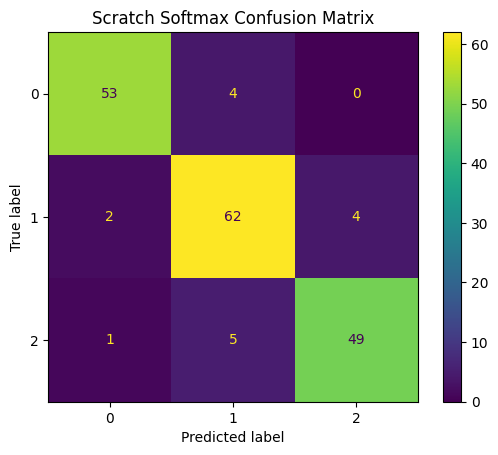

In [12]:
softmax_scratch = SoftmaxRegressionScratch(learning_rate=0.1, n_iterations=2000)
softmax_scratch.fit(X_train, y_train_onehot)
y_pred_scratch = softmax_scratch.predict(X_test)

print("Scratch Softmax Regression Accuracy:", accuracy_score(y_test, y_pred_scratch))

cm = confusion_matrix(y_test, y_pred_scratch)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
disp.plot(cmap="viridis")
plt.title("Scratch Softmax Confusion Matrix")
plt.show()

# **Implementing Scikit Learn's Model**

In [13]:
softmax_sklearn = LogisticRegression(multi_class="multinomial", max_iter=2000)
softmax_sklearn.fit(X_train, y_train)
y_pred_sklearn = softmax_sklearn.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Sklearn Softmax Regression Accuracy: 0.9055555555555556


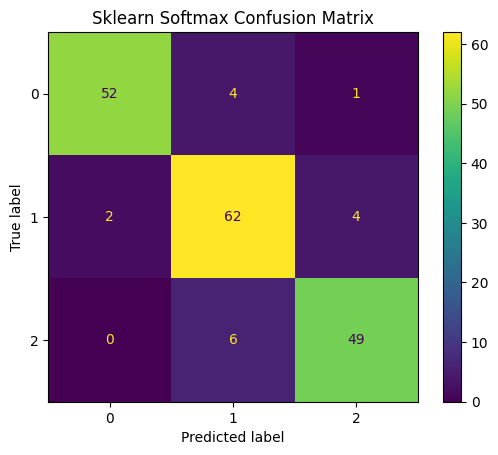

In [14]:
print("Sklearn Softmax Regression Accuracy:", accuracy_score(y_test, y_pred_sklearn))

cm = confusion_matrix(y_test, y_pred_sklearn)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
disp.plot(cmap="viridis")
plt.title("Sklearn Softmax Confusion Matrix")
plt.show()

# **Comparision Between Models**

Scratch Accuracy: 0.9111111111111111
Sklearn Accuracy: 0.9055555555555556


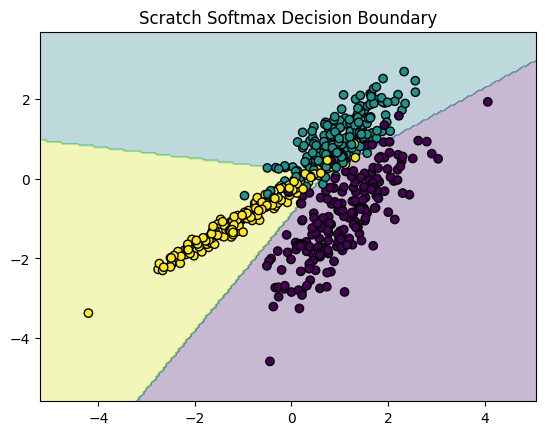

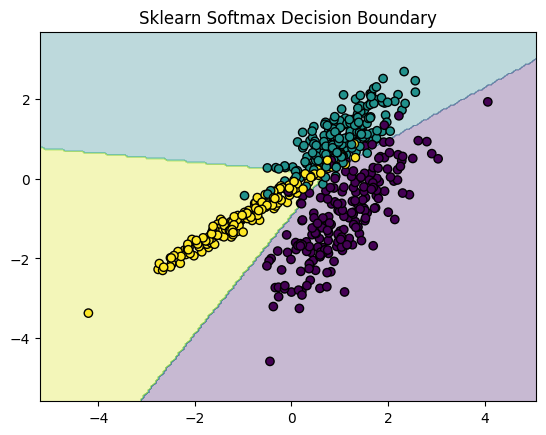

In [15]:
# Accuracies
scratch_acc = accuracy_score(y_test, y_pred_scratch)
sklearn_acc = accuracy_score(y_test, y_pred_sklearn)

print("Scratch Accuracy:", scratch_acc)
print("Sklearn Accuracy:", sklearn_acc)

# Decision boundary plot
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid)
    Z = preds.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap='viridis')
    plt.title(title)
    plt.show()

# Scratch decision boundary
plot_decision_boundary(softmax_scratch, X, y, "Scratch Softmax Decision Boundary")

# Sklearn decision boundary
plot_decision_boundary(softmax_sklearn, X, y, "Sklearn Softmax Decision Boundary")
